# HOG + LBP + KAZE → SVM / Random Forest
## Kaş Bölgesi Deepfake Tespiti — Nazlıcan / Deney 1

Bu notebook daha önce **kaş bölgesine kırpılmış ROI framelerini** kullanır.

**Girdi**
`/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş`

Beklenen yapı:

```text
Kaş/
├── real/
│   ├── train/*.jpg
│   ├── val/*.jpg
│   └── test/*.jpg
├── fake/
│   ├── train/*.jpg
│   ├── val/*.jpg
│   └── test/*.jpg
├── metadata.csv
└── ...
```

Bu notebook **yeniden kaş kırpma yapmaz** ve kaynak ROI dosyalarını değiştirmez.  
HOG, LBP ve KAZE özellikleri eğitim sırasında çıkarılır.

### Deneyler
- **E1:** HOG + LBP → RBF-SVM
- **E2:** HOG + LBP + KAZE → RBF-SVM
- **E3:** HOG + LBP + KAZE → Random Forest

### Standart çıktı
`.../Nazlıcan/Deney 1/Sonuçlar/HOG_LBP_KAZE_SVM_RF_Kas_Deneyi_Sonuc_/`

```text
checkpoints/
logs/
metrics/
predictions/
figures/
artifacts/
config_resolved.yaml
requirements_lock.txt
environment.json
run_summary.json
output_manifest.csv
```

In [1]:
# ============================================================
# 1. ORTAM KURULUMU — KAZE UYUMLU OPENCV SABİTLEME
# ============================================================
#
# NEDEN?
# Colab'ın OpenCV 5.x wheel'ında KAZE Python binding'i bu ortamda
# bulunmuyor. Bu deney KAZE kullandığı için uyumlu OpenCV 4.13
# sürümünü sabitliyoruz.
#
# ÖNEMLİ:
# Aynı ortamda birden fazla opencv-* paketi bırakmıyoruz.
# ============================================================

import sys
import subprocess

OPENCV_VERSION = "4.13.0.92"

print("OpenCV paketleri temizleniyor...")

subprocess.run(
    [
        sys.executable, "-m", "pip", "uninstall", "-y",
        "opencv-python",
        "opencv-python-headless",
        "opencv-contrib-python",
        "opencv-contrib-python-headless",
    ],
    check=False,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

print(f"opencv-contrib-python-headless=={OPENCV_VERSION} kuruluyor...")

subprocess.run(
    [
        sys.executable, "-m", "pip", "install",
        "--no-cache-dir",
        "--quiet",
        f"opencv-contrib-python-headless=={OPENCV_VERSION}",
        "scikit-image",
        "scikit-learn",
        "joblib",
        "pyyaml",
    ],
    check=True,
)

# OpenCV kurulumu bittikten sonra import ediyoruz.
import os
import cv2
import json
import yaml
import time
import joblib
import random
import hashlib
import logging
import platform
import warnings

from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog, local_binary_pattern

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print()
print("Python :", sys.version.split()[0])
print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)

# Bu notebook özellikle OpenCV 4.13.0.92 bekliyor.
if not str(cv2.__version__).startswith("4.13."):
    raise RuntimeError(
        "Beklenen OpenCV 4.13.x yüklenmedi. "
        f"Mevcut sürüm: {cv2.__version__}. "
        "Runtime > Restart session yapıp bu hücreyi yeniden çalıştır."
    )

# KAZE API doğrulaması.
if hasattr(cv2, "KAZE_create"):
    KAZE_FACTORY = cv2.KAZE_create
    KAZE_API = "cv2.KAZE_create()"
elif hasattr(cv2, "KAZE") and hasattr(cv2.KAZE, "create"):
    KAZE_FACTORY = cv2.KAZE.create
    KAZE_API = "cv2.KAZE.create()"
else:
    raise RuntimeError(
        "OpenCV 4.13 kuruldu ancak KAZE API yine bulunamadı. "
        f"Mevcut cv2 sürümü: {cv2.__version__}. "
        "Runtime > Restart session yapıp ilk hücreyi tekrar çalıştır."
    )

# Gerçek KAZE nesnesi oluşturarak son kontrol.
_kaze_test = KAZE_FACTORY()

if _kaze_test is None:
    raise RuntimeError("KAZE nesnesi oluşturulamadı.")

del _kaze_test

print("KAZE   : ✅ Kullanılabilir")
print("KAZE API:", KAZE_API)
print()
print("✅ OpenCV/KAZE ortam kontrolü başarılı.")

OpenCV paketleri temizleniyor...
opencv-contrib-python-headless==4.13.0.92 kuruluyor...

Python : 3.12.13
OpenCV : 4.13.0
NumPy  : 2.0.2
Pandas : 2.2.2
KAZE   : ✅ Kullanılabilir
KAZE API: cv2.KAZE_create()

✅ OpenCV/KAZE ortam kontrolü başarılı.


In [2]:
# ============================================================
# 2. GOOGLE DRIVE + DENEY YOLLARI + STANDART ÇIKTI KLASÖRLERİ
# ============================================================

from google.colab import drive

drive.mount("/content/drive", force_remount=False)

EXPERIMENT_ROOT = Path(
    "/content/drive/MyDrive/AISC DeepFake Çalışmaları/"
    "Deneyler/Nazlıcan/Deney 1"
)

DATASET_DIR = EXPERIMENT_ROOT / "Kaş"
RESULTS_ROOT = EXPERIMENT_ROOT / "Sonuçlar"

RUN_NAME = "HOG_LBP_KAZE_SVM_RF_Kas_Deneyi_Sonuc_"
RUN_DIR = RESULTS_ROOT / RUN_NAME

CHECKPOINTS_DIR = RUN_DIR / "checkpoints"
LOGS_DIR = RUN_DIR / "logs"
METRICS_DIR = RUN_DIR / "metrics"
PREDICTIONS_DIR = RUN_DIR / "predictions"
FIGURES_DIR = RUN_DIR / "figures"
ARTIFACTS_DIR = RUN_DIR / "artifacts"
FEATURE_CHUNKS_DIR = ARTIFACTS_DIR / "feature_chunks"

for d in [
    RESULTS_ROOT,
    RUN_DIR,
    CHECKPOINTS_DIR,
    LOGS_DIR,
    METRICS_DIR,
    PREDICTIONS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
    FEATURE_CHUNKS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Kaş veri klasörü bulunamadı: {DATASET_DIR}")

RUN_ID = datetime.now(ZoneInfo("Europe/Istanbul")).strftime(
    "%Y%m%d_%H%M%S_eyebrow_hog_lbp_kaze_seed42"
)

LOG_FILE = LOGS_DIR / "training.log"

logger = logging.getLogger("eyebrow_deepfake")
logger.setLevel(logging.INFO)
logger.handlers.clear()

fh = logging.FileHandler(LOG_FILE, mode="w", encoding="utf-8")
sh = logging.StreamHandler(sys.stdout)
fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
fh.setFormatter(fmt)
sh.setFormatter(fmt)
logger.addHandler(fh)
logger.addHandler(sh)

EXPERIMENT_START_TIME = time.time()

logger.info("Run ID: %s", RUN_ID)
logger.info("Dataset: %s", DATASET_DIR)
logger.info("Output : %s", RUN_DIR)

print("✅ Deney kökü :", EXPERIMENT_ROOT)
print("✅ Kaş verisi :", DATASET_DIR)
print("✅ Sonuç      :", RUN_DIR)

Mounted at /content/drive
2026-08-08 09:19:03,648 | INFO | Run ID: 20260808_121903_eyebrow_hog_lbp_kaze_seed42


INFO:eyebrow_deepfake:Run ID: 20260808_121903_eyebrow_hog_lbp_kaze_seed42


2026-08-08 09:19:03,670 | INFO | Dataset: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş


INFO:eyebrow_deepfake:Dataset: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş


2026-08-08 09:19:03,677 | INFO | Output : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/HOG_LBP_KAZE_SVM_RF_Kas_Deneyi_Sonuc_


INFO:eyebrow_deepfake:Output : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/HOG_LBP_KAZE_SVM_RF_Kas_Deneyi_Sonuc_


✅ Deney kökü : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1
✅ Kaş verisi : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş
✅ Sonuç      : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/HOG_LBP_KAZE_SVM_RF_Kas_Deneyi_Sonuc_


In [3]:
# ============================================================
# 3. KAŞ ROI VERİ SETİNİ TARA
# Yapı: real|fake / train|val|test / image.jpg
# real=0, fake=1
# ============================================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for class_name in ["real", "fake"]:
    label = 0 if class_name == "real" else 1

    for split_name in ["train", "val", "test"]:
        split_dir = DATASET_DIR / class_name / split_name

        if not split_dir.exists():
            raise FileNotFoundError(
                f"Beklenen klasör bulunamadı: {split_dir}"
            )

        image_files = sorted(
            p for p in split_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )

        for image_path in image_files:
            records.append({
                "image_path": str(image_path),
                "relative_path": image_path.relative_to(DATASET_DIR).as_posix(),
                "file_name": image_path.name,
                "class_name": class_name,
                "label": label,
                "split": split_name,
            })

dataset_df = pd.DataFrame(records)

if dataset_df.empty:
    raise ValueError("Kaş klasöründe eğitim görüntüsü bulunamadı.")

dataset_df = dataset_df.sort_values(
    ["split", "class_name", "file_name"]
).reset_index(drop=True)

if dataset_df["image_path"].duplicated().any():
    raise ValueError("Aynı ROI yolu birden fazla kez bulundu.")

# Kaş ROI üretim metadata'sını mümkünse ekle.
SOURCE_METADATA_FILE = DATASET_DIR / "metadata.csv"

if SOURCE_METADATA_FILE.exists():
    source_metadata_df = pd.read_csv(SOURCE_METADATA_FILE)

    if "output_relative_path" in source_metadata_df.columns:
        source_metadata_df["relative_path"] = (
            source_metadata_df["output_relative_path"]
            .astype(str)
            .str.replace("\\", "/", regex=False)
        )

        keep_columns = [
            c for c in [
                "relative_path",
                "sample_id",
                "source_video",
                "frame_index",
                "face_index",
                "status",
                "output_sha256",
                "roi_width",
                "roi_height",
                "blur_score",
                "eye_landmark_fraction",
            ]
            if c in source_metadata_df.columns
        ]

        source_small = (
            source_metadata_df[keep_columns]
            .drop_duplicates("relative_path", keep="last")
        )

        dataset_df = dataset_df.merge(
            source_small,
            on="relative_path",
            how="left",
        )

        logger.info("metadata.csv eğitim indeksine birleştirildi.")
    else:
        logger.warning("metadata.csv içinde output_relative_path yok.")
else:
    logger.warning("Kaş metadata.csv bulunamadı.")

accounting_df = (
    dataset_df.groupby(["split", "class_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["train", "val", "test"], fill_value=0)
    .reindex(columns=["real", "fake"], fill_value=0)
)

display(accounting_df)

print("Toplam:", len(dataset_df))
print("Train :", int((dataset_df["split"] == "train").sum()))
print("Val   :", int((dataset_df["split"] == "val").sum()))
print("Test  :", int((dataset_df["split"] == "test").sum()))

for split_name in ["train", "val", "test"]:
    labels = set(
        dataset_df.loc[dataset_df["split"] == split_name, "label"]
    )
    if labels != {0, 1}:
        raise ValueError(
            f"{split_name} splitinde iki sınıf da yok: {labels}"
        )

dataset_df.to_csv(
    ARTIFACTS_DIR / "dataset_index.csv",
    index=False,
    encoding="utf-8-sig",
)

logger.info("Kullanılan ROI sayısı: %d", len(dataset_df))

2026-08-08 09:19:18,977 | INFO | metadata.csv eğitim indeksine birleştirildi.


INFO:eyebrow_deepfake:metadata.csv eğitim indeksine birleştirildi.


class_name,real,fake
split,,
train,786,776
val,106,98
test,101,95


Toplam: 1962
Train : 1562
Val   : 204
Test  : 196
2026-08-08 09:19:19,123 | INFO | Kullanılan ROI sayısı: 1962


INFO:eyebrow_deepfake:Kullanılan ROI sayısı: 1962


In [4]:
# ============================================================
# 4. SPLIT / LEAKAGE AUDIT
# ============================================================

split_audit = {
    "exact_roi_hash_audit": {
        "status": "NOT_AVAILABLE",
        "cross_split_duplicate_hashes": None,
    },
    "source_video_audit": {
        "status": "NOT_AVAILABLE",
        "cross_split_source_videos": None,
    },
}

# ROI hash bilgisi metadata'da varsa aynı görüntünün farklı splitte
# bulunup bulunmadığını kontrol et.
if "output_sha256" in dataset_df.columns:
    hash_df = dataset_df.dropna(subset=["output_sha256"]).copy()
    hash_df["output_sha256"] = (
        hash_df["output_sha256"].astype(str).str.strip()
    )
    hash_df = hash_df[hash_df["output_sha256"].ne("")]

    if not hash_df.empty:
        hash_split_counts = (
            hash_df.groupby("output_sha256")["split"].nunique()
        )
        duplicate_hashes = hash_split_counts[
            hash_split_counts > 1
        ].index.tolist()

        split_audit["exact_roi_hash_audit"] = {
            "status": "PASSED" if not duplicate_hashes else "FAILED",
            "cross_split_duplicate_hashes": len(duplicate_hashes),
        }

# source_video gerçekten doluysa video-level izolasyonu doğrula.
if "source_video" in dataset_df.columns:
    video_df = dataset_df.dropna(subset=["source_video"]).copy()
    video_df["source_video"] = (
        video_df["source_video"].astype(str).str.strip()
    )
    video_df = video_df[
        ~video_df["source_video"].isin(
            ["", "nan", "None", "NOT_AVAILABLE"]
        )
    ]

    if not video_df.empty:
        video_split_counts = (
            video_df.groupby("source_video")["split"].nunique()
        )
        leaked_videos = video_split_counts[
            video_split_counts > 1
        ].index.tolist()

        split_audit["source_video_audit"] = {
            "status": "PASSED" if not leaked_videos else "FAILED",
            "cross_split_source_videos": len(leaked_videos),
            "examples": leaked_videos[:20],
        }

with open(
    METRICS_DIR / "split_audit.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(split_audit, f, indent=2, ensure_ascii=False)

print(json.dumps(split_audit, indent=2, ensure_ascii=False))

if split_audit["exact_roi_hash_audit"]["status"] == "FAILED":
    raise RuntimeError(
        "Aynı ROI içeriği birden fazla splitte bulundu. Eğitim durduruldu."
    )

if split_audit["source_video_audit"]["status"] == "FAILED":
    raise RuntimeError(
        "Aynı source_video birden fazla splitte bulundu. Eğitim durduruldu."
    )

{
  "exact_roi_hash_audit": {
    "status": "PASSED",
    "cross_split_duplicate_hashes": 0
  },
  "source_video_audit": {
    "status": "NOT_AVAILABLE",
    "cross_split_source_videos": null
  }
}


In [5]:
# ============================================================
# 5. HOG + LBP + KAZE FEATURE FONKSİYONLARI
# ============================================================

IMAGE_SIZE = (224, 224)

HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

LBP_RADIUS = 3
LBP_POINTS = 8 * LBP_RADIUS
LBP_METHOD = "uniform"
LBP_BINS = LBP_POINTS + 2

KAZE_DESCRIPTOR_LENGTH = 64

kaze_detector = KAZE_FACTORY()


def load_and_preprocess_image(image_path):
    """Hazır kaş ROI'sini okuyup 224x224 gri görüntüye dönüştürür."""
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if image is None:
        raise ValueError(f"Görüntü okunamadı: {image_path}")

    image = cv2.resize(
        image,
        IMAGE_SIZE,
        interpolation=cv2.INTER_AREA,
    )
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


def extract_hog_features(gray):
    """Kaş konturu ve lokal yönelim değişimlerini temsil eder."""
    return hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True,
    ).astype(np.float32)


def extract_lbp_features(gray):
    """Kaş çevresindeki lokal mikro-doku örüntülerini temsil eder."""
    lbp_image = local_binary_pattern(
        gray,
        P=LBP_POINTS,
        R=LBP_RADIUS,
        method=LBP_METHOD,
    )

    histogram, _ = np.histogram(
        lbp_image.ravel(),
        bins=np.arange(0, LBP_BINS + 1),
        range=(0, LBP_BINS),
    )

    histogram = histogram.astype(np.float32)
    histogram /= histogram.sum() + 1e-8
    return histogram


def extract_kaze_features(gray):
    """
    KAZE descriptor boyutu görüntüden görüntüye değiştiği için
    descriptor mean + std kullanılır: 64 + 64 = 128 özellik.
    """
    keypoints, descriptors = kaze_detector.detectAndCompute(gray, None)
    keypoint_count = len(keypoints)

    if descriptors is None or len(descriptors) == 0:
        return (
            np.zeros(KAZE_DESCRIPTOR_LENGTH * 2, dtype=np.float32),
            0,
        )

    descriptors = descriptors.astype(np.float32)

    vector = np.concatenate([
        descriptors.mean(axis=0),
        descriptors.std(axis=0),
    ]).astype(np.float32)

    return vector, keypoint_count


def extract_all_features(image_path):
    gray = load_and_preprocess_image(image_path)

    h = extract_hog_features(gray)
    l = extract_lbp_features(gray)
    k, kp = extract_kaze_features(gray)

    for vector in [h, l, k]:
        if np.isnan(vector).any() or np.isinf(vector).any():
            raise ValueError(f"NaN/Inf feature: {image_path}")

    return h, l, k, kp


sample_hog, sample_lbp, sample_kaze, sample_kp = (
    extract_all_features(dataset_df.iloc[0]["image_path"])
)

HOG_LENGTH = len(sample_hog)
LBP_LENGTH = len(sample_lbp)
KAZE_LENGTH = len(sample_kaze)
FUSED_LENGTH = HOG_LENGTH + LBP_LENGTH + KAZE_LENGTH

print("HOG  :", HOG_LENGTH)
print("LBP  :", LBP_LENGTH)
print("KAZE :", KAZE_LENGTH)
print("Fused:", FUSED_LENGTH)

assert HOG_LENGTH == 6084
assert LBP_LENGTH == 26
assert KAZE_LENGTH == 128
assert FUSED_LENGTH == 6238

HOG  : 6084
LBP  : 26
KAZE : 128
Fused: 6238


In [6]:
# ============================================================
# 6. TÜM KAŞ ROI'LERİNDEN FEATURE ÇIKAR
# 250'lik chunk + resume desteği
# ============================================================

CHUNK_SIZE = 250

all_hog = []
all_lbp = []
all_kaze = []
all_labels = []
all_splits = []
all_paths = []
all_relative_paths = []
all_keypoints = []

total_samples = len(dataset_df)
total_chunks = int(np.ceil(total_samples / CHUNK_SIZE))

feature_start = time.time()

for chunk_idx, start_idx in enumerate(
    range(0, total_samples, CHUNK_SIZE),
    start=1,
):
    end_idx = min(start_idx + CHUNK_SIZE, total_samples)
    chunk_df = dataset_df.iloc[start_idx:end_idx].copy()

    chunk_file = (
        FEATURE_CHUNKS_DIR / f"features_{chunk_idx:04d}.npz"
    )

    expected_relative_paths = (
        chunk_df["relative_path"].astype(str).to_numpy()
    )

    cached_ok = False

    if chunk_file.exists():
        try:
            with np.load(chunk_file, allow_pickle=False) as cached:
                if np.array_equal(
                    cached["relative_paths"].astype(str),
                    expected_relative_paths,
                ):
                    chunk_hog = cached["hog"].astype(np.float32)
                    chunk_lbp = cached["lbp"].astype(np.float32)
                    chunk_kaze = cached["kaze"].astype(np.float32)
                    chunk_labels = cached["labels"].astype(np.int64)
                    chunk_splits = cached["splits"].astype(str)
                    chunk_paths = cached["image_paths"].astype(str)
                    chunk_rel = cached["relative_paths"].astype(str)
                    chunk_kp = cached["kaze_keypoints"].astype(np.int32)
                    cached_ok = True
        except Exception:
            cached_ok = False

    if cached_ok:
        print(
            f"♻️ {chunk_idx}/{total_chunks} cache kullanıldı "
            f"[{start_idx}:{end_idx}]"
        )
    else:
        print(
            f"⚙️ {chunk_idx}/{total_chunks} işleniyor "
            f"[{start_idx}:{end_idx}]"
        )

        h_rows, l_rows, k_rows, kp_rows = [], [], [], []

        for _, row in chunk_df.iterrows():
            h, l, k, kp = extract_all_features(row["image_path"])
            h_rows.append(h)
            l_rows.append(l)
            k_rows.append(k)
            kp_rows.append(kp)

        chunk_hog = np.vstack(h_rows).astype(np.float32)
        chunk_lbp = np.vstack(l_rows).astype(np.float32)
        chunk_kaze = np.vstack(k_rows).astype(np.float32)

        chunk_labels = chunk_df["label"].to_numpy(dtype=np.int64)
        chunk_splits = chunk_df["split"].astype(str).to_numpy()
        chunk_paths = chunk_df["image_path"].astype(str).to_numpy()
        chunk_rel = expected_relative_paths
        chunk_kp = np.asarray(kp_rows, dtype=np.int32)

        np.savez_compressed(
            chunk_file,
            hog=chunk_hog,
            lbp=chunk_lbp,
            kaze=chunk_kaze,
            labels=chunk_labels,
            splits=chunk_splits,
            image_paths=chunk_paths,
            relative_paths=chunk_rel,
            kaze_keypoints=chunk_kp,
        )

    all_hog.append(chunk_hog)
    all_lbp.append(chunk_lbp)
    all_kaze.append(chunk_kaze)
    all_labels.append(chunk_labels)
    all_splits.append(chunk_splits)
    all_paths.append(chunk_paths)
    all_relative_paths.append(chunk_rel)
    all_keypoints.append(chunk_kp)

X_hog = np.vstack(all_hog).astype(np.float32)
X_lbp = np.vstack(all_lbp).astype(np.float32)
X_kaze = np.vstack(all_kaze).astype(np.float32)

y_all = np.concatenate(all_labels).astype(np.int64)
split_all = np.concatenate(all_splits).astype(str)
image_paths_all = np.concatenate(all_paths).astype(str)
relative_paths_all = np.concatenate(all_relative_paths).astype(str)
kaze_keypoints_all = np.concatenate(all_keypoints).astype(np.int32)

X_hog_lbp = np.hstack([X_hog, X_lbp]).astype(np.float32)
X_fused = np.hstack([X_hog, X_lbp, X_kaze]).astype(np.float32)

assert X_hog.shape == (total_samples, HOG_LENGTH)
assert X_lbp.shape == (total_samples, LBP_LENGTH)
assert X_kaze.shape == (total_samples, KAZE_LENGTH)
assert X_fused.shape == (total_samples, FUSED_LENGTH)
assert not np.isnan(X_fused).any()
assert not np.isinf(X_fused).any()

np.savez_compressed(
    ARTIFACTS_DIR / "features_full.npz",
    hog=X_hog,
    lbp=X_lbp,
    kaze=X_kaze,
    labels=y_all,
    splits=split_all,
    image_paths=image_paths_all,
    relative_paths=relative_paths_all,
    kaze_keypoints=kaze_keypoints_all,
)

pd.DataFrame({
    "relative_path": relative_paths_all,
    "label": y_all,
    "split": split_all,
    "kaze_keypoints": kaze_keypoints_all,
}).to_csv(
    ARTIFACTS_DIR / "feature_metadata.csv",
    index=False,
    encoding="utf-8-sig",
)

feature_minutes = (time.time() - feature_start) / 60

print(f"✅ Feature extraction: {feature_minutes:.2f} dk")
print("HOG+LBP shape :", X_hog_lbp.shape)
print("Fused shape   :", X_fused.shape)
print(
    "KAZE keypoint mean:",
    f"{kaze_keypoints_all.mean():.2f}",
)

⚙️ 1/8 işleniyor [0:250]
⚙️ 2/8 işleniyor [250:500]
⚙️ 3/8 işleniyor [500:750]
⚙️ 4/8 işleniyor [750:1000]
⚙️ 5/8 işleniyor [1000:1250]
⚙️ 6/8 işleniyor [1250:1500]
⚙️ 7/8 işleniyor [1500:1750]
⚙️ 8/8 işleniyor [1750:1962]
✅ Feature extraction: 20.15 dk
HOG+LBP shape : (1962, 6110)
Fused shape   : (1962, 6238)
KAZE keypoint mean: 9.35


In [7]:
# ============================================================
# 7. TRAIN / VAL / TEST + METRİK YARDIMCILARI
# ============================================================

train_mask = split_all == "train"
val_mask = split_all == "val"
test_mask = split_all == "test"

X_train_hog_lbp = X_hog_lbp[train_mask]
X_val_hog_lbp = X_hog_lbp[val_mask]
X_test_hog_lbp = X_hog_lbp[test_mask]

X_train_fused = X_fused[train_mask]
X_val_fused = X_fused[val_mask]
X_test_fused = X_fused[test_mask]

y_train = y_all[train_mask]
y_val = y_all[val_mask]
y_test = y_all[test_mask]

test_relative_paths = relative_paths_all[test_mask]

for name, y in [
    ("train", y_train),
    ("val", y_val),
    ("test", y_test),
]:
    if set(np.unique(y)) != {0, 1}:
        raise ValueError(f"{name}: iki sınıf da bulunmalı.")

data_accounting = {
    "total_samples": int(len(y_all)),
    "train_samples": int(len(y_train)),
    "validation_samples": int(len(y_val)),
    "test_samples": int(len(y_test)),
    "train_real": int((y_train == 0).sum()),
    "train_fake": int((y_train == 1).sum()),
    "validation_real": int((y_val == 0).sum()),
    "validation_fake": int((y_val == 1).sum()),
    "test_real": int((y_test == 0).sum()),
    "test_fake": int((y_test == 1).sum()),
}

with open(
    METRICS_DIR / "data_accounting.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(data_accounting, f, indent=2, ensure_ascii=False)

print(data_accounting)


def evaluate_binary(y_true, predictions, scores):
    cm = confusion_matrix(y_true, predictions, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": float(accuracy_score(y_true, predictions)),
        "precision_fake": float(
            precision_score(
                y_true, predictions, pos_label=1, zero_division=0
            )
        ),
        "recall_fake": float(
            recall_score(
                y_true, predictions, pos_label=1, zero_division=0
            )
        ),
        "f1_fake": float(
            f1_score(
                y_true, predictions, pos_label=1, zero_division=0
            )
        ),
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "specificity_real": float(
            tn / (tn + fp) if (tn + fp) > 0 else 0.0
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "confusion_matrix": cm,
    }


def best_validation_row(df):
    return (
        df.sort_values(
            ["validation_f1_fake", "validation_roc_auc"],
            ascending=False,
        )
        .iloc[0]
    )


def atomic_joblib_save(model, target_path):
    target_path = Path(target_path)
    tmp = Path(str(target_path) + ".tmp")

    joblib.dump(model, tmp)
    _ = joblib.load(tmp)
    os.replace(tmp, target_path)

{'total_samples': 1962, 'train_samples': 1562, 'validation_samples': 204, 'test_samples': 196, 'train_real': 786, 'train_fake': 776, 'validation_real': 106, 'validation_fake': 98, 'test_real': 101, 'test_fake': 95}


In [8]:
# ============================================================
# 8. E1 — HOG + LBP → RBF-SVM
# ============================================================

C_VALUES = [0.1, 1.0, 10.0]

e1_rows = []
e1_models = {}

for c_value in C_VALUES:
    start = time.time()

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svc",
            SVC(
                C=c_value,
                kernel="rbf",
                gamma="scale",
                class_weight="balanced",
                probability=False,
                cache_size=2000,
            ),
        ),
    ])

    model.fit(X_train_hog_lbp, y_train)

    val_pred = model.predict(X_val_hog_lbp)
    val_scores = model.decision_function(X_val_hog_lbp)
    m = evaluate_binary(y_val, val_pred, val_scores)

    e1_rows.append({
        "experiment_id": "E1",
        "model": "HOG + LBP - RBF-SVM",
        "C": c_value,
        "validation_accuracy": m["accuracy"],
        "validation_precision_fake": m["precision_fake"],
        "validation_recall_fake": m["recall_fake"],
        "validation_f1_fake": m["f1_fake"],
        "validation_roc_auc": m["roc_auc"],
        "training_minutes": (time.time() - start) / 60,
    })

    e1_models[float(c_value)] = model

e1_validation_df = pd.DataFrame(e1_rows)
best_e1 = best_validation_row(e1_validation_df)
best_baseline_c = float(best_e1["C"])
best_baseline_model = e1_models[best_baseline_c]

e1_test_pred = best_baseline_model.predict(X_test_hog_lbp)
e1_test_scores = best_baseline_model.decision_function(X_test_hog_lbp)
e1_metrics = evaluate_binary(y_test, e1_test_pred, e1_test_scores)

display(
    e1_validation_df.sort_values(
        ["validation_f1_fake", "validation_roc_auc"],
        ascending=False,
    )
)
print("Selected C:", best_baseline_c)
print("Test metrics:", {k:v for k,v in e1_metrics.items() if k != "confusion_matrix"})

,experiment_id,model,C,validation_accuracy,validation_precision_fake,validation_recall_fake,validation_f1_fake,validation_roc_auc,training_minutes
2,E1,HOG + LBP - RBF-SVM,10.0,0.617647,0.589286,0.673469,0.628571,0.610897,0.347379
0,E1,HOG + LBP - RBF-SVM,0.1,0.553922,0.526718,0.704082,0.602620,0.564786,0.417025
1,E1,HOG + LBP - RBF-SVM,1.0,0.593137,0.577320,0.571429,0.574359,0.631594,0.652463


Selected C: 10.0
Test metrics: {'accuracy': 0.4897959183673469, 'precision_fake': 0.47706422018348627, 'recall_fake': 0.5473684210526316, 'f1_fake': 0.5098039215686274, 'roc_auc': 0.48702449192287645, 'specificity_real': 0.43564356435643564, 'tn': 44, 'fp': 57, 'fn': 43, 'tp': 52}


In [9]:
# ============================================================
# 9. E2 — HOG + LBP + KAZE → RBF-SVM
# ============================================================

e2_rows = []
e2_models = {}

for c_value in C_VALUES:
    start = time.time()

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svc",
            SVC(
                C=c_value,
                kernel="rbf",
                gamma="scale",
                class_weight="balanced",
                probability=False,
                cache_size=2000,
            ),
        ),
    ])

    model.fit(X_train_fused, y_train)

    val_pred = model.predict(X_val_fused)
    val_scores = model.decision_function(X_val_fused)
    m = evaluate_binary(y_val, val_pred, val_scores)

    e2_rows.append({
        "experiment_id": "E2",
        "model": "HOG + LBP + KAZE - RBF-SVM",
        "C": c_value,
        "validation_accuracy": m["accuracy"],
        "validation_precision_fake": m["precision_fake"],
        "validation_recall_fake": m["recall_fake"],
        "validation_f1_fake": m["f1_fake"],
        "validation_roc_auc": m["roc_auc"],
        "training_minutes": (time.time() - start) / 60,
    })

    e2_models[float(c_value)] = model

e2_validation_df = pd.DataFrame(e2_rows)
best_e2 = best_validation_row(e2_validation_df)
best_fused_svm_c = float(best_e2["C"])
best_fused_svm_model = e2_models[best_fused_svm_c]

e2_test_pred = best_fused_svm_model.predict(X_test_fused)
e2_test_scores = best_fused_svm_model.decision_function(X_test_fused)
e2_metrics = evaluate_binary(y_test, e2_test_pred, e2_test_scores)

display(
    e2_validation_df.sort_values(
        ["validation_f1_fake", "validation_roc_auc"],
        ascending=False,
    )
)
print("Selected C:", best_fused_svm_c)
print("Test metrics:", {k:v for k,v in e2_metrics.items() if k != "confusion_matrix"})

,experiment_id,model,C,validation_accuracy,validation_precision_fake,validation_recall_fake,validation_f1_fake,validation_roc_auc,training_minutes
1,E2,HOG + LBP + KAZE - RBF-SVM,1.0,0.627451,0.610000,0.622449,0.616162,0.641317,0.388640
0,E2,HOG + LBP + KAZE - RBF-SVM,0.1,0.539216,0.515152,0.693878,0.591304,0.574894,0.386252
2,E2,HOG + LBP + KAZE - RBF-SVM,10.0,0.583333,0.559633,0.622449,0.589372,0.617251,0.390570


Selected C: 1.0
Test metrics: {'accuracy': 0.5306122448979592, 'precision_fake': 0.5161290322580645, 'recall_fake': 0.5052631578947369, 'f1_fake': 0.5106382978723404, 'roc_auc': 0.5388223032829599, 'specificity_real': 0.5544554455445545, 'tn': 56, 'fp': 45, 'fn': 47, 'tp': 48}


In [10]:
# ============================================================
# 10. E3 — HOG + LBP + KAZE → RANDOM FOREST
# ============================================================

RF_CONFIGURATIONS = [
    {
        "name": "RF-1",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
    },
    {
        "name": "RF-2",
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
    },
    {
        "name": "RF-3",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
    },
]

e3_rows = []
e3_models = {}

for config in RF_CONFIGURATIONS:
    start = time.time()

    model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_features=config["max_features"],
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )

    model.fit(X_train_fused, y_train)

    val_pred = model.predict(X_val_fused)
    val_prob = model.predict_proba(X_val_fused)[:, 1]
    m = evaluate_binary(y_val, val_pred, val_prob)

    e3_rows.append({
        "experiment_id": "E3",
        "model": "HOG + LBP + KAZE - Random Forest",
        "configuration": config["name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_leaf": config["min_samples_leaf"],
        "max_features": config["max_features"],
        "validation_accuracy": m["accuracy"],
        "validation_precision_fake": m["precision_fake"],
        "validation_recall_fake": m["recall_fake"],
        "validation_f1_fake": m["f1_fake"],
        "validation_roc_auc": m["roc_auc"],
        "training_minutes": (time.time() - start) / 60,
    })

    e3_models[config["name"]] = model

e3_validation_df = pd.DataFrame(e3_rows)
best_e3 = best_validation_row(e3_validation_df)
best_rf_name = str(best_e3["configuration"])
best_rf_model = e3_models[best_rf_name]

best_rf_configuration = next(
    c for c in RF_CONFIGURATIONS
    if c["name"] == best_rf_name
)

e3_test_pred = best_rf_model.predict(X_test_fused)
e3_test_prob = best_rf_model.predict_proba(X_test_fused)[:, 1]
e3_metrics = evaluate_binary(y_test, e3_test_pred, e3_test_prob)

display(
    e3_validation_df.sort_values(
        ["validation_f1_fake", "validation_roc_auc"],
        ascending=False,
    )
)
print("Selected RF:", best_rf_configuration)
print("Test metrics:", {k:v for k,v in e3_metrics.items() if k != "confusion_matrix"})

,experiment_id,model,configuration,n_estimators,max_depth,min_samples_leaf,max_features,validation_accuracy,validation_precision_fake,validation_recall_fake,validation_f1_fake,validation_roc_auc,training_minutes
0,E3,HOG + LBP + KAZE - Random Forest,RF-1,300,NaN,1,sqrt,0.651961,0.639175,0.632653,0.635897,0.653398,0.585287
2,E3,HOG + LBP + KAZE - Random Forest,RF-3,300,NaN,2,sqrt,0.637255,0.620000,0.632653,0.626263,0.649981,0.531610
1,E3,HOG + LBP + KAZE - Random Forest,RF-2,300,20.0,1,sqrt,0.637255,0.622449,0.622449,0.622449,0.653494,0.566050


Selected RF: {'name': 'RF-1', 'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Test metrics: {'accuracy': 0.5255102040816326, 'precision_fake': 0.5113636363636364, 'recall_fake': 0.47368421052631576, 'f1_fake': 0.4918032786885246, 'roc_auc': 0.5556539864512767, 'specificity_real': 0.5742574257425742, 'tn': 58, 'fp': 43, 'fn': 50, 'tp': 45}


,experiment_id,model,selected_parameter,accuracy,precision_fake,recall_fake,f1_fake,roc_auc,specificity_real,tn,fp,fn,tp
0,E1,HOG + LBP - RBF-SVM,C=10.0,0.489796,0.477064,0.547368,0.509804,0.487024,0.435644,44,57,43,52
1,E2,HOG + LBP + KAZE - RBF-SVM,C=1.0,0.530612,0.516129,0.505263,0.510638,0.538822,0.554455,56,45,47,48
2,E3,HOG + LBP + KAZE - Random Forest,RF-1,0.525510,0.511364,0.473684,0.491803,0.555654,0.574257,58,43,50,45


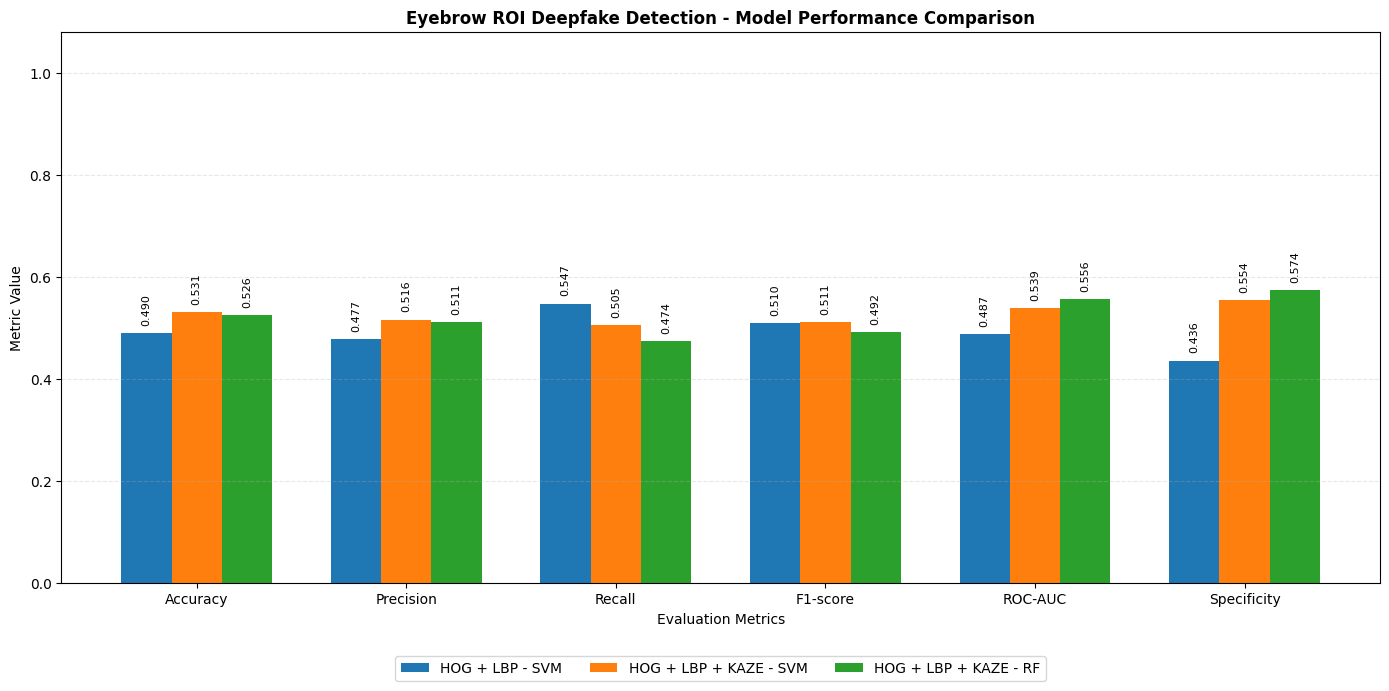

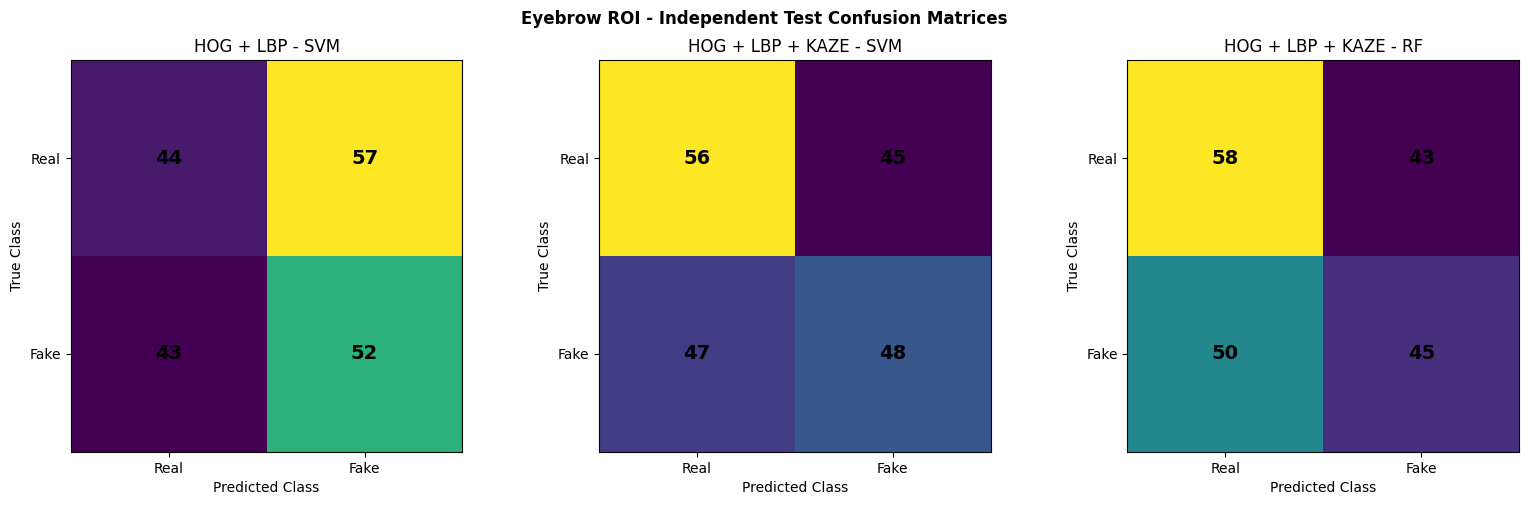

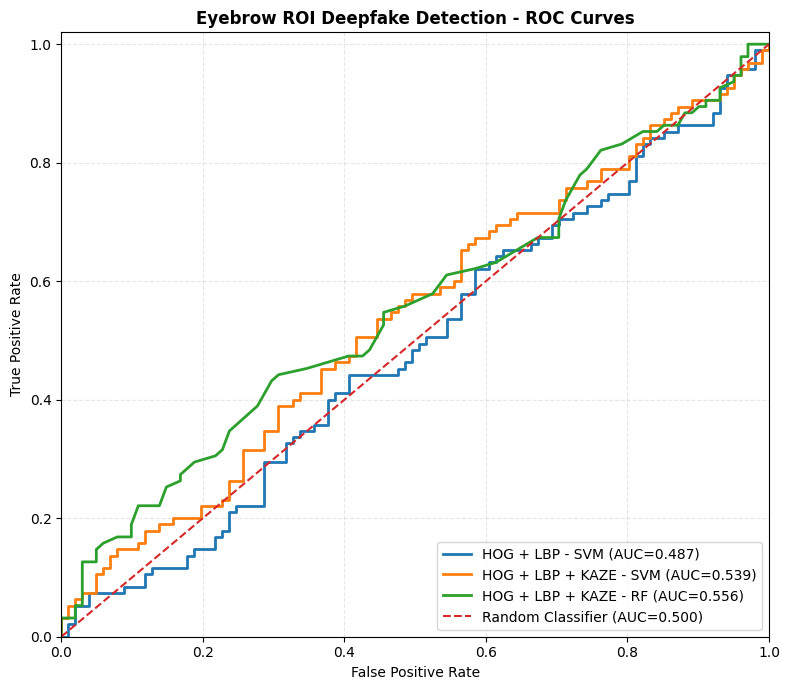

2026-08-08 09:51:05,878 | INFO | Standart model/metrik/tahmin/grafik çıktıları kaydedildi.


INFO:eyebrow_deepfake:Standart model/metrik/tahmin/grafik çıktıları kaydedildi.


In [11]:
# ============================================================
# 11. STANDART SONUÇ PAKETİNİ KAYDET
# checkpoints / metrics / predictions / figures
# ============================================================

# ------------------- checkpoints ----------------------------

MODEL_E1_FILE = CHECKPOINTS_DIR / "best_hog_lbp_rbf_svm.joblib"
MODEL_E2_FILE = CHECKPOINTS_DIR / "best_hog_lbp_kaze_rbf_svm.joblib"
MODEL_E3_FILE = CHECKPOINTS_DIR / "best_hog_lbp_kaze_random_forest.joblib"

atomic_joblib_save(best_baseline_model, MODEL_E1_FILE)
atomic_joblib_save(best_fused_svm_model, MODEL_E2_FILE)
atomic_joblib_save(best_rf_model, MODEL_E3_FILE)

# Fresh-load inference test
reload_e1 = joblib.load(MODEL_E1_FILE)
reload_e2 = joblib.load(MODEL_E2_FILE)
reload_e3 = joblib.load(MODEL_E3_FILE)

assert np.array_equal(
    reload_e1.predict(X_test_hog_lbp),
    e1_test_pred,
)
assert np.array_equal(
    reload_e2.predict(X_test_fused),
    e2_test_pred,
)
assert np.array_equal(
    reload_e3.predict(X_test_fused),
    e3_test_pred,
)

with open(
    METRICS_DIR / "fresh_load_inference_test.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        {"status": "PASSED", "models_checked": 3},
        f,
        indent=2,
    )

# ---------------------- metrics ------------------------------

e1_validation_df.to_csv(
    METRICS_DIR / "hog_lbp_svm_validation_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
e2_validation_df.to_csv(
    METRICS_DIR / "hog_lbp_kaze_svm_validation_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
e3_validation_df.to_csv(
    METRICS_DIR / "hog_lbp_kaze_rf_validation_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)


def final_metric_row(experiment_id, model, selected, metrics):
    return {
        "experiment_id": experiment_id,
        "model": model,
        "selected_parameter": selected,
        "accuracy": metrics["accuracy"],
        "precision_fake": metrics["precision_fake"],
        "recall_fake": metrics["recall_fake"],
        "f1_fake": metrics["f1_fake"],
        "roc_auc": metrics["roc_auc"],
        "specificity_real": metrics["specificity_real"],
        "tn": metrics["tn"],
        "fp": metrics["fp"],
        "fn": metrics["fn"],
        "tp": metrics["tp"],
    }


final_metrics_df = pd.DataFrame([
    final_metric_row(
        "E1",
        "HOG + LBP - RBF-SVM",
        f"C={best_baseline_c}",
        e1_metrics,
    ),
    final_metric_row(
        "E2",
        "HOG + LBP + KAZE - RBF-SVM",
        f"C={best_fused_svm_c}",
        e2_metrics,
    ),
    final_metric_row(
        "E3",
        "HOG + LBP + KAZE - Random Forest",
        best_rf_name,
        e3_metrics,
    ),
])

final_metrics_df.to_csv(
    METRICS_DIR / "final_test_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
display(final_metrics_df)

for model_key, predictions in {
    "E1_HOG_LBP_SVM": e1_test_pred,
    "E2_HOG_LBP_KAZE_SVM": e2_test_pred,
    "E3_HOG_LBP_KAZE_RF": e3_test_pred,
}.items():
    pd.DataFrame(
        classification_report(
            y_test,
            predictions,
            labels=[0, 1],
            target_names=["real", "fake"],
            output_dict=True,
            zero_division=0,
        )
    ).T.to_csv(
        METRICS_DIR / f"classification_report_{model_key}.csv",
        encoding="utf-8-sig",
    )

# -------------------- predictions ----------------------------

test_predictions_df = pd.DataFrame({
    "relative_path": test_relative_paths,
    "true_label_id": y_test,
    "true_label": np.where(y_test == 1, "fake", "real"),
    "e1_prediction_id": e1_test_pred,
    "e1_prediction": np.where(e1_test_pred == 1, "fake", "real"),
    "e1_decision_score": e1_test_scores,
    "e2_prediction_id": e2_test_pred,
    "e2_prediction": np.where(e2_test_pred == 1, "fake", "real"),
    "e2_decision_score": e2_test_scores,
    "e3_prediction_id": e3_test_pred,
    "e3_prediction": np.where(e3_test_pred == 1, "fake", "real"),
    "e3_fake_probability": e3_test_prob,
    "run_id": RUN_ID,
})

test_metadata = dataset_df[
    dataset_df["split"] == "test"
].copy()

extra_cols = [
    c for c in [
        "relative_path",
        "sample_id",
        "source_video",
        "frame_index",
        "face_index",
        "output_sha256",
    ]
    if c in test_metadata.columns
]

if len(extra_cols) > 1:
    test_predictions_df = test_predictions_df.merge(
        test_metadata[extra_cols],
        on="relative_path",
        how="left",
    )

test_predictions_df.to_csv(
    PREDICTIONS_DIR / "test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

# ---------------------- figures ------------------------------

MODEL_NAMES = [
    "HOG + LBP - SVM",
    "HOG + LBP + KAZE - SVM",
    "HOG + LBP + KAZE - RF",
]

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "Specificity",
]

metric_matrix = np.array([
    [
        e1_metrics["accuracy"],
        e1_metrics["precision_fake"],
        e1_metrics["recall_fake"],
        e1_metrics["f1_fake"],
        e1_metrics["roc_auc"],
        e1_metrics["specificity_real"],
    ],
    [
        e2_metrics["accuracy"],
        e2_metrics["precision_fake"],
        e2_metrics["recall_fake"],
        e2_metrics["f1_fake"],
        e2_metrics["roc_auc"],
        e2_metrics["specificity_real"],
    ],
    [
        e3_metrics["accuracy"],
        e3_metrics["precision_fake"],
        e3_metrics["recall_fake"],
        e3_metrics["f1_fake"],
        e3_metrics["roc_auc"],
        e3_metrics["specificity_real"],
    ],
])

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(metric_names))
width = 0.24

for idx, name in enumerate(MODEL_NAMES):
    bars = ax.bar(
        x + (idx - 1) * width,
        metric_matrix[idx],
        width=width,
        label=name,
    )

    for bar, value in zip(bars, metric_matrix[idx]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            min(value + 0.015, 1.04),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

ax.set_title(
    "Eyebrow ROI Deepfake Detection - Model Performance Comparison",
    fontweight="bold",
)
ax.set_xlabel("Evaluation Metrics")
ax.set_ylabel("Metric Value")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.08)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "model_performance_comparison.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
plt.close(fig)

cms = [
    e1_metrics["confusion_matrix"],
    e2_metrics["confusion_matrix"],
    e3_metrics["confusion_matrix"],
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, cm, name in zip(axes, cms, MODEL_NAMES):
    ax.imshow(cm)

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
            )

    ax.set_title(name)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.set_xticks([0, 1], labels=["Real", "Fake"])
    ax.set_yticks([0, 1], labels=["Real", "Fake"])

fig.suptitle(
    "Eyebrow ROI - Independent Test Confusion Matrices",
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "confusion_matrices.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
plt.close(fig)

e1_fpr, e1_tpr, _ = roc_curve(y_test, e1_test_scores)
e2_fpr, e2_tpr, _ = roc_curve(y_test, e2_test_scores)
e3_fpr, e3_tpr, _ = roc_curve(y_test, e3_test_prob)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(
    e1_fpr, e1_tpr, linewidth=2,
    label=f"{MODEL_NAMES[0]} (AUC={e1_metrics['roc_auc']:.3f})",
)
ax.plot(
    e2_fpr, e2_tpr, linewidth=2,
    label=f"{MODEL_NAMES[1]} (AUC={e2_metrics['roc_auc']:.3f})",
)
ax.plot(
    e3_fpr, e3_tpr, linewidth=2,
    label=f"{MODEL_NAMES[2]} (AUC={e3_metrics['roc_auc']:.3f})",
)
ax.plot(
    [0, 1], [0, 1],
    linestyle="--",
    label="Random Classifier (AUC=0.500)",
)
ax.set_title(
    "Eyebrow ROI Deepfake Detection - ROC Curves",
    fontweight="bold",
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(linestyle="--", alpha=0.3)
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "roc_curves.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
plt.close(fig)

logger.info("Standart model/metrik/tahmin/grafik çıktıları kaydedildi.")

In [12]:
# ============================================================
# 12. CONFIG + ENVIRONMENT + AUDIT + SUMMARY + MANIFEST
# ============================================================

import sklearn
import skimage

experiment_seconds = time.time() - EXPERIMENT_START_TIME

resolved_config = {
    "run_id": RUN_ID,
    "run_name": RUN_NAME,
    "region": "eyebrow",
    "seed": SEED,
    "dataset": {
        "path": str(DATASET_DIR),
        **data_accounting,
        "label_mapping": {"real": 0, "fake": 1},
        "split_source": "pre-existing real|fake/train|val|test folders",
        "input_images_modified": False,
        "source_metadata": (
            str(SOURCE_METADATA_FILE)
            if SOURCE_METADATA_FILE.exists()
            else None
        ),
    },
    "features": {
        "image_size": list(IMAGE_SIZE),
        "hog": {
            "orientations": HOG_ORIENTATIONS,
            "pixels_per_cell": list(HOG_PIXELS_PER_CELL),
            "cells_per_block": list(HOG_CELLS_PER_BLOCK),
            "length": HOG_LENGTH,
        },
        "lbp": {
            "radius": LBP_RADIUS,
            "points": LBP_POINTS,
            "method": LBP_METHOD,
            "length": LBP_LENGTH,
        },
        "kaze": {
            "pooling": "descriptor mean + descriptor std",
            "length": KAZE_LENGTH,
        },
        "fused_length": FUSED_LENGTH,
    },
    "model_selection": {
        "selection_split": "validation",
        "primary_metric": "f1_fake",
        "secondary_metric": "roc_auc",
        "test_used_for_selection": False,
    },
    "models": {
        "E1": {
            "name": "HOG + LBP - RBF-SVM",
            "selected_C": best_baseline_c,
        },
        "E2": {
            "name": "HOG + LBP + KAZE - RBF-SVM",
            "selected_C": best_fused_svm_c,
        },
        "E3": {
            "name": "HOG + LBP + KAZE - Random Forest",
            **best_rf_configuration,
        },
    },
    "split_audit": split_audit,
}

with open(
    RUN_DIR / "config_resolved.yaml",
    "w",
    encoding="utf-8",
) as f:
    yaml.safe_dump(
        resolved_config,
        f,
        allow_unicode=True,
        sort_keys=False,
    )

environment = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "opencv": cv2.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "scikit_image": skimage.__version__,
}

with open(
    RUN_DIR / "environment.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(environment, f, indent=2, ensure_ascii=False)

freeze = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True,
    text=True,
    check=False,
)

with open(
    RUN_DIR / "requirements_lock.txt",
    "w",
    encoding="utf-8",
) as f:
    f.write(freeze.stdout)

source_video_status = split_audit[
    "source_video_audit"
]["status"]
hash_status = split_audit[
    "exact_roi_hash_audit"
]["status"]

audit_lines = [
    f"Run ID: {RUN_ID}",
    "Region: eyebrow",
    f"Seed: {SEED}",
    "",
    f"Total ROI samples: {len(y_all)}",
    f"Training samples: {len(y_train)}",
    f"Validation samples: {len(y_val)}",
    f"Test samples: {len(y_test)}",
    "",
    "Raw/cropped eyebrow ROI files modified: NO",
    "Features extracted during experiment: YES",
    "NaN or Inf detected: NO",
    "Test set used for model selection: NO",
    "Saved-model inference reload test: PASSED",
    f"Exact ROI hash cross-split audit: {hash_status}",
    f"Source-video cross-split audit: {source_video_status}",
]

if source_video_status == "NOT_AVAILABLE":
    audit_lines.extend([
        "",
        "NOTE:",
        "source_video bilgisi metadata içinde dolu olmadığı için",
        "video-level split izolasyonu bağımsız doğrulanamadı.",
        "Mevcut train/val/test klasörleri aynen korunmuştur.",
    ])

with open(
    LOGS_DIR / "audit_summary.txt",
    "w",
    encoding="utf-8",
) as f:
    f.write("\n".join(audit_lines))

run_summary = {
    "run_id": RUN_ID,
    "run_name": RUN_NAME,
    "region": "eyebrow",
    "status": "COMPLETED",
    "duration_seconds": round(experiment_seconds, 3),
    "data_accounting": data_accounting,
    "split_audit": split_audit,
    "selected_models": {
        "E1_C": best_baseline_c,
        "E2_C": best_fused_svm_c,
        "E3_configuration": best_rf_configuration,
    },
    "test_metrics": {
        "E1": {
            k: v for k, v in e1_metrics.items()
            if k != "confusion_matrix"
        },
        "E2": {
            k: v for k, v in e2_metrics.items()
            if k != "confusion_matrix"
        },
        "E3": {
            k: v for k, v in e3_metrics.items()
            if k != "confusion_matrix"
        },
    },
}

with open(
    RUN_DIR / "run_summary.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(run_summary, f, indent=2, ensure_ascii=False)


def sha256_file(file_path):
    h = hashlib.sha256()

    with open(file_path, "rb") as f:
        for block in iter(
            lambda: f.read(1024 * 1024),
            b"",
        ):
            h.update(block)

    return h.hexdigest()


manifest_rows = []

for file_path in sorted(RUN_DIR.rglob("*")):
    if not file_path.is_file():
        continue

    if file_path.name == "output_manifest.csv":
        continue

    manifest_rows.append({
        "relative_path": file_path.relative_to(RUN_DIR).as_posix(),
        "size_bytes": file_path.stat().st_size,
        "sha256": sha256_file(file_path),
    })

pd.DataFrame(manifest_rows).to_csv(
    RUN_DIR / "output_manifest.csv",
    index=False,
    encoding="utf-8-sig",
)

logger.info(
    "Experiment completed in %.2f minutes",
    experiment_seconds / 60,
)

print("=" * 80)
print("✅ DENEY TAMAMLANDI")
print("Run ID        :", RUN_ID)
print("Sonuç klasörü :", RUN_DIR)
print("Toplam ROI    :", len(y_all))
print("E1 Test F1    :", f"{e1_metrics['f1_fake']:.4f}")
print("E2 Test F1    :", f"{e2_metrics['f1_fake']:.4f}")
print("E3 Test F1    :", f"{e3_metrics['f1_fake']:.4f}")
print("=" * 80)

print("\nStandart klasörler:")
for d in [
    CHECKPOINTS_DIR,
    LOGS_DIR,
    METRICS_DIR,
    PREDICTIONS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
]:
    print("📁", d)

2026-08-08 09:51:45,373 | INFO | Experiment completed in 32.60 minutes


INFO:eyebrow_deepfake:Experiment completed in 32.60 minutes


✅ DENEY TAMAMLANDI
Run ID        : 20260808_121903_eyebrow_hog_lbp_kaze_seed42
Sonuç klasörü : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/HOG_LBP_KAZE_SVM_RF_Kas_Deneyi_Sonuc_
Toplam ROI    : 1962
E1 Test F1    : 0.5098
E2 Test F1    : 0.5106
E3 Test F1    : 0.4918

Standart klasörler:
📁 /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/HOG_LBP_KAZE_SVM_RF_Kas_Deneyi_Sonuc_/checkpoints
📁 /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/HOG_LBP_KAZE_SVM_RF_Kas_Deneyi_Sonuc_/logs
📁 /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/HOG_LBP_KAZE_SVM_RF_Kas_Deneyi_Sonuc_/metrics
📁 /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/HOG_LBP_KAZE_SVM_RF_Kas_Deneyi_Sonuc_/predictions
📁 /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/HOG_LBP_KAZE_SVM_RF_Kas_Deneyi_Sonuc_/figures
📁 /cont

## Çalıştırma

Notebooku **yukarıdan aşağıya** çalıştır.

İlk tam çalıştırmada HOG/LBP/KAZE özellikleri çıkarıldığı için feature aşaması zaman alabilir.  
Tamamlanan feature chunkları `artifacts/feature_chunks/` altında saklanır; çalışma kesilirse aynı veri yapısıyla yeniden çalıştırıldığında uygun chunklar cache'den yüklenir.

`source_video` metadata alanı doluysa video-level leakage kontrolü otomatik yapılır. Alan boşsa sonuç paketi bunu `NOT_AVAILABLE` olarak raporlar; video-level izolasyon doğrulanmış gibi gösterilmez.